# PDAC Regression Analysis Model
## Late-Stage Diagnosis & Healthcare Access

### *Research Question*:

How do regional differences in healthcare access influence late-stage diagnosis rates of Pancreatic Ductal Adenocarcinoma (PDAC) across the global population and Canada?

### *Data Sources:*

**Global Burden of Disease (GBD) via IHME GBD Results Tool**
- World Deaths From Pancreatic Cancer (% of Population)
- Canada Deaths From Pancreatic Cancer (% of Population)
- Global Incidence Rate Per Year (Per 100,000 People)
- Canada Incidence Rate Per Year (Per 100,000 People)
- Canada Prevalence of Pancreatic Cancer

**WHO Global Health Observatory**
- UHC Service Coverage Index
- Hospital Beds Per 10,000 Population
- Medical Doctors Per 10,000 Population

**World Bank Open Data (Word Development Indicators)**
- GDP Per Capita (Current US$)
- Current Health Expenditure (% of GDP)
- Rural Population (% of Total)

**UNDP Human Development Reports**
- Human Development Index (HDI)

All the data used in this analysis was downloaded in CSV format and imported into this notebook for cleaning, analysis, and visualization.

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os

from sklearn.linear_model import(
LinearRegression, Ridge, Lasso, RidgeCV, LassoCV
)
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [53]:
# Paths to uploaded CSVs

DATA = "data/"
os.makedirs(DATA, exist_ok=True)

PATH_WORLD_DEATHS  = "data/World Deaths from Pancreatic Cancer (% of Population).csv"
PATH_GLOBAL_INC    = "data/Global Incidence Rate Per Year (Per 100 000).csv"
PATH_CAN_INC       = "data/Canada Incidence Rate Per Year (Per 100 000).csv"
PATH_CAN_DEATHS    = "data/Canada Deaths from Pancreatic Cancer (% of Population).csv"
PATH_CAN_PREV      = "data/Prevalence of Pancreatic Cancer (Canada).csv"
PATH_UHC           = "data/UHC Service Coverage Index.csv"
PATH_BEDS          = "data/Hospital Beds Per 10 000 Population.csv"
PATH_DOCTORS       = "data/Medical Doctors Per 10 000 Population.csv"
PATH_GDP           = "data/GDP Per Capita (Current US$).csv"
PATH_HEALTH_EXP    = "data/Current Health Expenditure (% of GDP).csv"
PATH_RURAL         = "data/Rural Population (% of Total).csv"
PATH_HDI           = "data/Human Development Index (HDI).csv"

In [54]:
# Loading and Cleaning Data From CSV Files

# CSV: World Deaths From Pancreatic Cancer (% of Population)
world_deaths = pd.read_csv(PATH_WORLD_DEATHS)
world_deaths = world_deaths[["location_name", "year", "val"]].copy()
world_deaths.columns = ["country", "year", "death_pct"]
print(f"  World Deaths:  {len(world_deaths)} rows, {world_deaths['country'].nunique()} countries (2023)")

# CSV: UHC Service Coverage Index
uhc = pd.read_csv(PATH_UHC)
uhc_latest = uhc[uhc["DIM_TIME"] == 2021][["GEO_NAME_SHORT", "INDEX_N"]].copy()
uhc_latest.columns = ["country", "uhc_index"]
print(f"  UHC Index:     {len(uhc_latest)} countries (2021)")

# CSV: Hospital Beds Per 10 000 Population
beds = pd.read_csv(PATH_BEDS, encoding="utf-8-sig")
beds_latest = beds[beds["IsLatestYear"] == True][["Location", "FactValueNumeric"]].copy()
beds_latest.columns = ["country", "hospital_beds"]
print(f"  Hospital Beds: {len(beds_latest)} countries")

# CSV: Medical Doctors Per 10 000 Population
doctors = pd.read_csv(PATH_DOCTORS)
doctors = doctors.sort_values("Period", ascending=False).drop_duplicates(subset="Location")
doctors = doctors[["Location", "First Tooltip"]].copy()
doctors.columns = ["country", "physician_density"]
print(f"  Physicians:    {len(doctors)} countries")

# CSV: GDP Per Capita (Current US$)
gdp = pd.read_csv(PATH_GDP, skiprows=3, encoding="utf-8-sig")
gdp = gdp[["Country Name", "2021"]].dropna().copy()
gdp.columns = ["country", "gdp_per_capita"]
gdp["gdp_per_capita"] = pd.to_numeric(gdp["gdp_per_capita"], errors="coerce")
gdp = gdp.dropna()
print(f"  GDP/capita:    {len(gdp)} countries (2021)")

# CSV: Current Health Expenditure (% of GDP)
hexp = pd.read_csv(PATH_HEALTH_EXP, skiprows=3, encoding="utf-8-sig")
hexp = hexp[["Country Name", "2021"]].dropna().copy()
hexp.columns = ["country", "health_exp_pct_gdp"]
hexp["health_exp_pct_gdp"] = pd.to_numeric(hexp["health_exp_pct_gdp"], errors="coerce")
hexp = hexp.dropna()
print(f"  Health Exp:    {len(hexp)} countries (2021)")

# CSV: Rural Population (% of Total)
rural = pd.read_csv(PATH_RURAL, skiprows=3, encoding="utf-8-sig")
rural = rural[["Country Name", "2021"]].dropna().copy()
rural.columns = ["country", "rural_pop_pct"]
rural["rural_pop_pct"] = pd.to_numeric(rural["rural_pop_pct"], errors="coerce")
rural = rural.dropna()
print(f"  Rural Pop:     {len(rural)} countries (2021)")

# CSV: Human Development Index (HDI)
hdi_raw = pd.read_csv(PATH_HDI, header=None, encoding="utf-8-sig")
hdi_rows = []
for i in range(8, len(hdi_raw)):
    row = hdi_raw.iloc[i]
    country = str(row[1]).strip() if pd.notna(row[1]) else ""
    hdi_val = str(row[2]).strip() if pd.notna(row[2]) else ""
    if country and hdi_val and country not in [
        "Very high human development", "High human development",
        "Medium human development", "Low human development",
        "Developing Countries", "Regions", "Sub-Saharan Africa",
        "OECD", "World", "Arab States", "East Asia and the Pacific",
        "Europe and Central Asia", "Latin America and the Caribbean",
        "South Asia", "Least Developed Countries",
        "Small Island Developing States",
        "Organisation for Economic Co-operation and Development",
        "Human development groups"
    ]:
        try:
            hdi_rows.append({"country": country, "hdi": float(hdi_val)})
        except ValueError:
            pass
hdi = pd.DataFrame(hdi_rows)
print(f"  HDI:           {len(hdi)} countries (2023)")

  World Deaths:  204 rows, 204 countries (2023)
  UHC Index:     210 countries (2021)
  Hospital Beds: 193 countries
  Physicians:    194 countries
  GDP/capita:    258 countries (2021)
  Health Exp:    241 countries (2021)
  Rural Pop:     265 countries (2021)
  HDI:           196 countries (2023)


In [55]:
# Canada Data

can_inc = pd.read_csv(PATH_CAN_INC)[["year", "val"]].copy()
can_inc.columns = ["year", "incidence_rate"]
can_inc = can_inc.sort_values("year")

can_deaths = pd.read_csv(PATH_CAN_DEATHS)[["year", "val"]].copy()
can_deaths.columns = ["year", "death_pct"]
can_deaths = can_deaths.sort_values("year")

can_prev = pd.read_csv(PATH_CAN_PREV)[["year", "val"]].copy()
can_prev.columns = ["year", "prevalence_count"]
can_prev = can_prev.sort_values("year")

global_inc = pd.read_csv(PATH_GLOBAL_INC)[["year", "val"]].copy()
global_inc.columns = ["year", "incidence_rate"]
global_inc = global_inc.sort_values("year")

print(f"  Canada Incidence:  {len(can_inc)} years")
print(f"  Canada Deaths:     {len(can_deaths)} years")
print(f"  Canada Prevalence: {len(can_prev)} years")
print(f"  Global Incidence:  {len(global_inc)} years")

  Canada Incidence:  24 years
  Canada Deaths:     24 years
  Canada Prevalence: 24 years
  Global Incidence:  24 years


In [56]:
# standardizing country names
name_map = {
    "Türkiye": "Turkey",
    "Viet Nam": "Vietnam",
    "Republic of Korea": "South Korea",
    "Korea (Republic of)": "South Korea",
    "Korea, Rep.": "South Korea",
    "Russian Federation": "Russia",
    "Iran (Islamic Republic of)": "Iran",
    "Iran, Islamic Rep.": "Iran",
    "United States of America": "United States",
    "United Kingdom of Great Britain and Northern Ireland": "United Kingdom",
    "Venezuela (Bolivarian Republic of)": "Venezuela",
    "Venezuela, RB": "Venezuela",
    "Bolivia (Plurinational State of)": "Bolivia",
    "Congo, Dem. Rep.": "Democratic Republic of the Congo",
    "Democratic Republic of the Congo": "Democratic Republic of the Congo",
    "Congo, Rep.": "Congo",
    "Côte d'Ivoire": "Cote d'Ivoire",
    "Cote d'Ivoire": "Cote d'Ivoire",
    "Czechia": "Czech Republic",
    "Egypt, Arab Rep.": "Egypt",
    "Eswatini": "Eswatini",
    "Kyrgyz Republic": "Kyrgyzstan",
    "Lao People's Democratic Republic": "Laos",
    "Lao PDR": "Laos",
    "Micronesia (Federated States of)": "Micronesia",
    "Moldova (Republic of)": "Moldova",
    "Moldova": "Moldova",
    "Republic of Moldova": "Moldova",
    "North Macedonia": "North Macedonia",
    "Slovak Republic": "Slovakia",
    "Syrian Arab Republic": "Syria",
    "Tanzania (United Republic of)": "Tanzania",
    "Tanzania": "Tanzania",
    "Timor-Leste": "Timor-Leste",
    "Turkmenistan": "Turkmenistan",
    "Yemen, Rep.": "Yemen",
    "Gambia, The": "Gambia",
    "Hong Kong, China (SAR)": "Hong Kong",
    "Hong Kong SAR, China": "Hong Kong",
    "Macao SAR, China": "Macao",
    "West Bank and Gaza": "Palestine",
    "State of Palestine": "Palestine",
    "Cabo Verde": "Cape Verde",
    "Brunei Darussalam": "Brunei",
    "Micronesia, Fed. Sts.": "Micronesia",
    "St. Lucia": "Saint Lucia",
    "St. Vincent and the Grenadines": "Saint Vincent and the Grenadines",
    "St. Kitts and Nevis": "Saint Kitts and Nevis",
    "São Tomé and Príncipe": "Sao Tome and Principe",
    "Sao Tome and Principe": "Sao Tome and Principe",
}

def standardise_names(df, col="country"):
    df[col] = df[col].replace(name_map)
    return df

datasets = [world_deaths, uhc_latest, beds_latest, doctors, gdp, hexp, rural, hdi]
for ds in datasets:
    standardise_names(ds)

# merge
merged = world_deaths.copy()
for ds in [uhc_latest, beds_latest, doctors, gdp, hexp, rural, hdi]:
    merged = merged.merge(ds, on="country", how="inner")

merged = merged.dropna()
# Convert death_pct to deaths per 100,000 for more intuitive interpretation
merged["death_rate_per_100k"] = merged["death_pct"] * 100000

print(merged.describe().round(3).to_string())
print()

# defining variables
target     = "death_rate_per_100k"    # proxy for late-stage diagnosis
predictors = ["uhc_index", "hospital_beds", "physician_density",
              "gdp_per_capita", "health_exp_pct_gdp", "rural_pop_pct", "hdi"]

         year  death_pct  uhc_index  hospital_beds  physician_density  gdp_per_capita  health_exp_pct_gdp  rural_pop_pct      hdi  death_rate_per_100k
count   178.0    178.000    178.000        178.000            178.000         178.000             178.000        178.000  178.000              178.000
mean   2023.0      0.010     65.084         27.596             20.830       15917.407               7.191         39.624    0.747              974.358
std       0.0      0.008     14.700         21.897             16.569       22507.786               3.163         22.007    0.146              792.045
min    2023.0      0.000     29.000          1.540              0.380         264.980               2.147          0.000    0.414               21.218
25%    2023.0      0.003     53.000         10.730              5.290        2462.698               4.874         22.220    0.635              262.327
50%    2023.0      0.008     70.000         23.550             17.895        6019.128         

# Part 1 - Exploratory Data Analysis

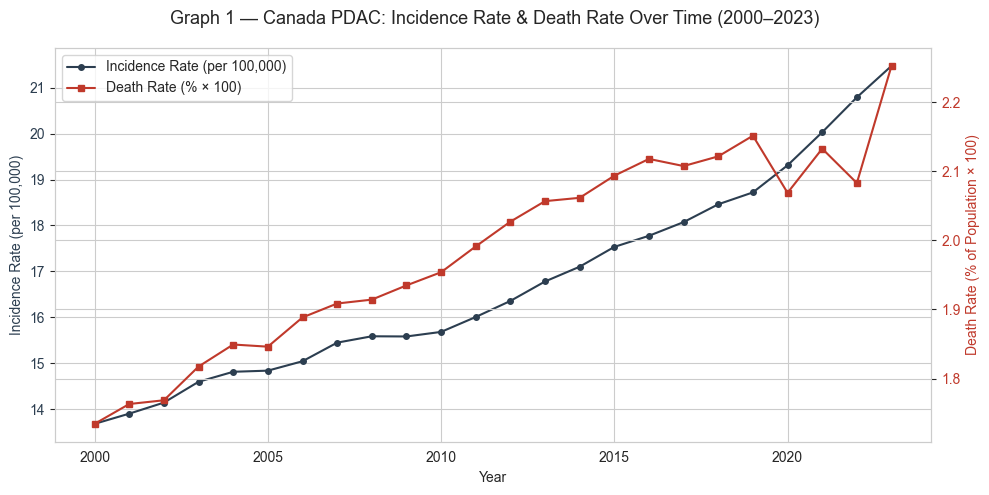

In [57]:
# Graph 1 - Canada PDAC Incidence & Death Trends Over Time
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(can_inc["year"], can_inc["incidence_rate"], "o-", color="#2c3e50",
         markersize=4, label="Incidence Rate (per 100,000)")
ax1.set_xlabel("Year")
ax1.set_ylabel("Incidence Rate (per 100,000)", color="#2c3e50")
ax1.tick_params(axis="y", labelcolor="#2c3e50")

ax2 = ax1.twinx()
ax2.plot(can_deaths["year"], can_deaths["death_pct"] * 100, "s-",
         color="#c0392b", markersize=4, label="Death Rate (% × 100)")
ax2.set_ylabel("Death Rate (% of Population × 100)", color="#c0392b")
ax2.tick_params(axis="y", labelcolor="#c0392b")

fig.suptitle("Graph 1 — Canada PDAC: Incidence Rate & Death Rate Over Time (2000–2023)",
             fontsize=13)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
plt.tight_layout()
plt.savefig("graph01_canada_trends.png")
plt.show()
plt.close()

Both the incidence and death rates are rising steadily in Canada, with the death rate increasing more sharply in recent years. This suggests that not only are more cases being diagnosed, but also that a higher proportion may be presenting at late stages where mortality is higher.

There is a divergence between the incidence and death trendlines, which could indicate worsening prognosis or delays in diagnosis and treatment. The rising incidence may reflect better detection. The two lines track each other closely, which further confirms PDAC's high lethality (almost everyone diagnosed eventually dies from it). The spike in the red line around 2020-21 followed by a dip likely reflects disruptions from COVID-19 (delayed diagnosing led to a surge of late-stage cases and then a temporary drop as fewer people were diagnosed at all).

The divergence between incidence and death trends could indicate worsening prognosis or delays in diagnosis and treatment.

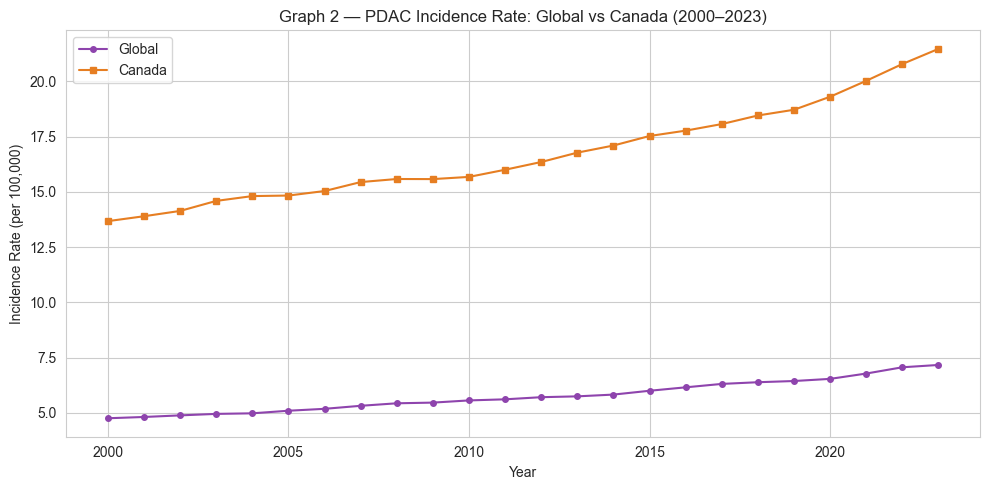

In [58]:
# Graph 2 - Global vs Canada Incidence Rate Comparison
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(global_inc["year"], global_inc["incidence_rate"], "o-",
        label="Global", color="#8e44ad", markersize=4)
ax.plot(can_inc["year"], can_inc["incidence_rate"], "s-",
        label="Canada", color="#e67e22", markersize=4)
ax.set_xlabel("Year")
ax.set_ylabel("Incidence Rate (per 100,000)")
ax.set_title("Graph 2 — PDAC Incidence Rate: Global vs Canada (2000–2023)")
ax.legend()
plt.tight_layout()
plt.savefig("graph02_global_vs_canada_incidence.png")
plt.show()
plt.close()

Canada's PDAC incidence rate is consistently higher than the global average, with the gap widening over time. This could be due to better detection and reporting in Canada, and the diagnosic capacity is improving over time. The Canadian population is a mix of people from various ethnicities and genetics, so the higher incidence is unlikely to be due to genetic factors alone.

Another explanation could be that environmental and lifestyle factors, such as higher rates of obesity, smoking, and diabetes in Canada, may contribute to the increased incidence.

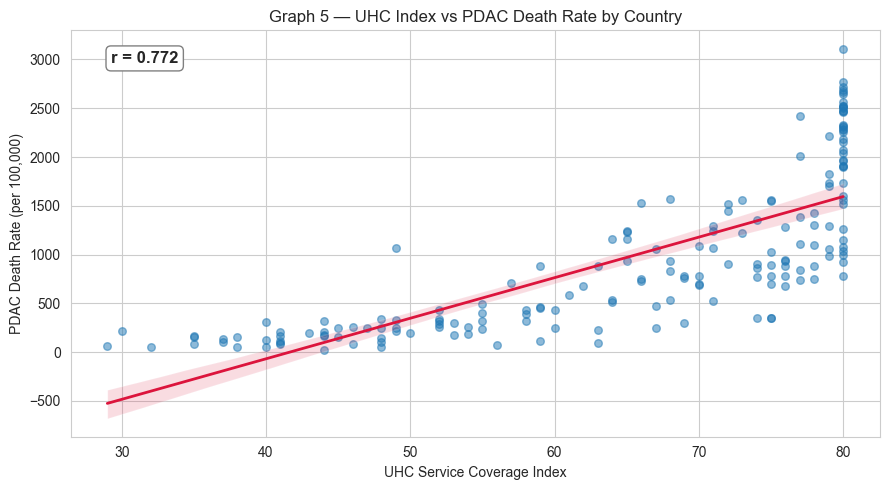

In [59]:
# Graph 5 - UHC Index vs PDAC Death Rate
fig, ax = plt.subplots(figsize=(9, 5))
sns.regplot(data=merged, x="uhc_index", y="death_rate_per_100k",
            scatter_kws={"alpha": 0.5, "s": 30},
            line_kws={"color": "crimson", "lw": 2}, ax=ax)
ax.set_xlabel("UHC Service Coverage Index")
ax.set_ylabel("PDAC Death Rate (per 100,000)")
ax.set_title("Graph 5 — UHC Index vs PDAC Death Rate by Country")
r_val = merged["uhc_index"].corr(merged["death_rate_per_100k"])
ax.annotate(f"r = {r_val:.3f}", xy=(0.05, 0.92), xycoords="axes fraction",
            fontsize=12, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray"))
plt.tight_layout()
plt.savefig("graph05_uhc_vs_death_rate.png")
plt.show()
plt.close()

There is a moderate/strong positive correlation between UHC index and PDAC mortality (r = 0.772). This is rather counterintuitive as we expect better healthcare access to lead to lower death rates. However, this likely reflects better detection and reporting in countries with higher UHC, rather than a causal relationship between UHC index and death rates.

The shaded crimson band around the regression line shows the 95% condience interval (if we repeated this study many times with different random samples of countries, the true regression line would fall inside the band 95% of the time). Most countries have UHC scores clustered in the middle range, so the band is tight. Fewer countries sit at the extremes, so the band widens there.

# Section 2 - Regression Modelling

In [60]:
# setting up for regression modelling
X = merged[predictors].values
y = merged[target].values

# standardizing features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42
)
print(f"  Train: {len(y_train)} samples,  Test: {len(y_test)} samples\n")

  Train: 142 samples,  Test: 36 samples



In [61]:
# Simple Linear Regression (UHC Index as Predictor of PDAC Death Rate)
# y = β₀ + β₁X + ε
uhc_col = predictors.index("uhc_index")
X_uhc_train = X_train[:, uhc_col].reshape(-1, 1)
X_uhc_test  = X_test[:, uhc_col].reshape(-1, 1)

slr = LinearRegression()
slr.fit(X_uhc_train, y_train)
y_pred_slr = slr.predict(X_uhc_test)

print("Simple Linear Regression (UHC Index as Predictor of PDAC Death Rate)")
print(f"    Coefficient (Slope): {slr.coef_[0]:.4f}")
print(f"    Intercept:           {slr.intercept_:.4f}")
print(f"    R² (test):           {r2_score(y_test, y_pred_slr):.4f}")
print(f"    MSE (test):          {mean_squared_error(y_test, y_pred_slr):.4f}\n")

Simple Linear Regression (UHC Index as Predictor of PDAC Death Rate)
    Coefficient (Slope): 609.4606
    Intercept:           960.8765
    R² (test):           0.6541
    MSE (test):          207852.2420



The simple linear regression model trains on 80% of countries and tests on the remaining 20%
* coefficient (slope) = 609.4606

for every 1 point increase in UHC index, the model predits ~609 more PDAC deaths per 100,000.
* intercept = 960.8765

the predicted death rate when UHC = 0
* R^2 = 0.6541

UHC index alone explains 65.41% of the variance in PDAC death rates across countries
* MSE = 207852.2420

on average, the squared difference between predicted and actual death rates is 207852.2420

In [62]:
# Multiple Linear Regression of All Variables
# y = β₀ + β₁X₁ + ... + βₙXₙ + ε
mlr = LinearRegression()
mlr.fit(X_train, y_train)
y_pred_mlr = mlr.predict(X_test)

r2_mlr = r2_score(y_test, y_pred_mlr)
print("MULTIPLE LINEAR REGRESSION (all predictors)")
print(f"    R² (test):  {r2_mlr:.4f}")
print(f"    MSE (test): {mean_squared_error(y_test, y_pred_mlr):.4f}")
print(f"    MAE (test): {mean_absolute_error(y_test, y_pred_mlr):.4f}")
print("    Coefficients:")
for name, coef in sorted(zip(predictors, mlr.coef_), key=lambda x: abs(x[1]), reverse=True):
    print(f"      {name:25s}  {coef:+.4f}")
print()

MULTIPLE LINEAR REGRESSION (all predictors)
    R² (test):  0.8421
    MSE (test): 94884.5407
    MAE (test): 251.4071
    Coefficients:
      gdp_per_capita             +256.9260
      hdi                        +225.8440
      physician_density          +159.0303
      health_exp_pct_gdp         +101.5914
      hospital_beds              +93.6598
      rural_pop_pct              -69.3599
      uhc_index                  -2.6586



The multiple linear regression model, which includes all predictors, achieves a higher R² of 0.8123 compared to the simple linear regression with UHC alone (R² = 0.6541). This indicates that the additional predictors contribute to explaining more of the variance in PDAC death rates across countries. The MSE (94884.5407) and MAE (251.4071) are also significantly lower than the simple linear regression model, suggesting better predictive accuracy.

According to this model, which standardizes all predictors, the most influential factors (based on coefficient magnitude) in order from strongest to weakest are:

GDP per capita (+257), HDI (+226), phyisician density (+159), health expenditure (+102), hospital beds (+94), rural population (-70), UHC index (-2.6)

The UHC index is near zero and negative once all other variables are controlled for, suggesting that UHC's strong positive effect in the simple linear regression was largely because it was acting as a proxy for GDP, HDI, and physician density (which are all correlated with UHC index).

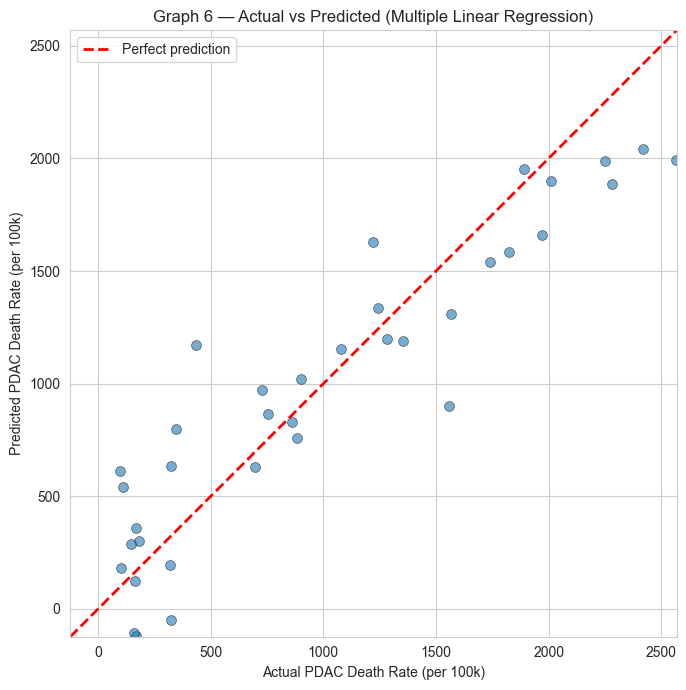

In [63]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test, y_pred_mlr, alpha=0.6, edgecolors="k", linewidth=0.5, s=50)
lims = [min(y_test.min(), y_pred_mlr.min()) - 1,
        max(y_test.max(), y_pred_mlr.max()) + 1]
ax.plot(lims, lims, "r--", lw=2, label="Perfect prediction")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("Actual PDAC Death Rate (per 100k)")
ax.set_ylabel("Predicted PDAC Death Rate (per 100k)")
ax.set_title("Graph 6 — Actual vs Predicted (Multiple Linear Regression)")
ax.legend()
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig("graph06_actual_vs_predicted.png")
plt.show()
plt.close()

Each dot is one country from the test set (20% of countries the model was not trained on). The overall trend follows the prediction well with a strong R^2 of 0.84. In the bottom left, the dots sit noticeably above the line, meaning that the model consistently over-predicts death rates for low-mortality countries. In the top right, the dots sit mostly below the line, meaning that the model under-predicts death rates for high-mortality countries. Also, the model produced negative predicted deaths for some countries which, combined with previous observations, may point at the linear model struggling at extremes.

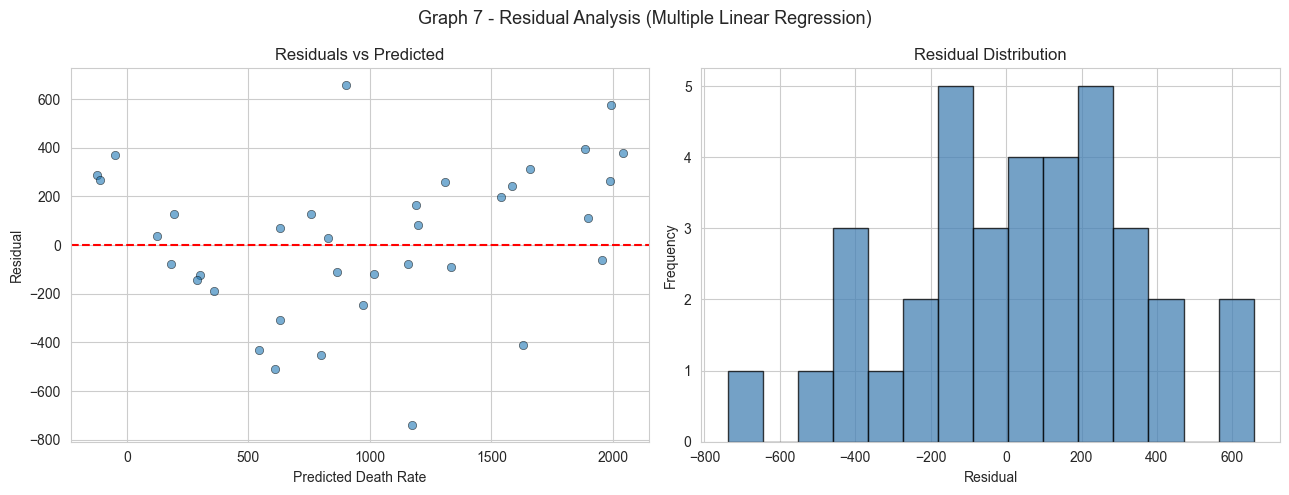

In [64]:
# Residual Analysis (Multilinear Regression)
residuals = y_test - y_pred_mlr
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_pred_mlr, residuals, alpha=0.6, edgecolors="k", linewidth=0.5)
axes[0].axhline(0, color="red", ls="--", lw=1.5)
axes[0].set_xlabel("Predicted Death Rate")
axes[0].set_ylabel("Residual")
axes[0].set_title("Residuals vs Predicted")

axes[1].hist(residuals, bins=15, edgecolor="black", color="steelblue", alpha=0.75)
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Residual Distribution")

fig.suptitle("Graph 7 - Residual Analysis (Multiple Linear Regression)", fontsize=13)
plt.tight_layout()
plt.savefig("graph07_residual_analysis.png")
plt.show()
plt.close()

A residual is the actual value - predicted value for each country (with a value of 0 meaning perfect prediction)

In the left plot, dots scattered randomly and evenly above and below zero indicates that the model's errors are random and not systematically biased. However, we see that residuals are not perfectly random and show a pattern where the model tends to over-predict for low death rates (residuals mostly positive) and under-predict for high death rates (residuals mostly negative). This indicates heteroscedasticity (the models' erros are not constant across the range of predicted values).

In the right plot, the histogram of residuals should ideally show a bell-shaped curve centered around zero, indicating that the errors are normally distributed. However, we see a left-skewed distribution where there are more extreme negative residuals than extreme positive ones, which again suggests that the model is under-predicting for high death rates.


  POLYNOMIAL REGRESSION (UHC Index → Death Rate)
    Degree 1:  R² = 0.6541,  MSE = 207852.2420
    Degree 2:  R² = 0.7315,  MSE = 161333.8687
    Degree 3:  R² = 0.7301,  MSE = 162170.3431
    Degree 5:  R² = 0.6986,  MSE = 181104.9075


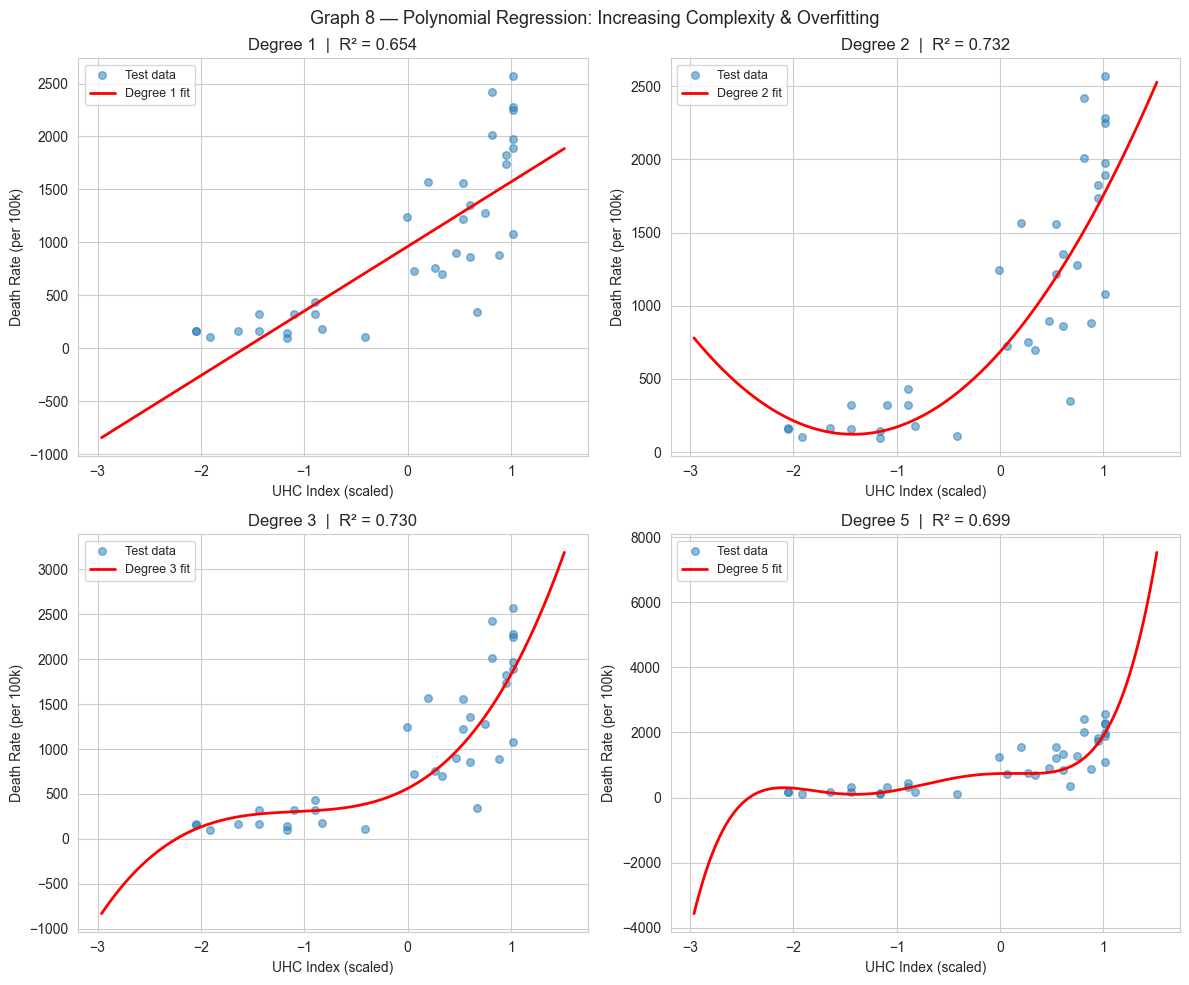

In [65]:
# POLYNOMIAL REGRESSION
print("\n  POLYNOMIAL REGRESSION (UHC Index → Death Rate)")

degrees = [1, 2, 3, 5]
poly_results = {}
fig, axes_p = plt.subplots(2, 2, figsize=(12, 10))
axes_p = axes_p.ravel()

for i, deg in enumerate(degrees):
    poly = PolynomialFeatures(degree=deg, include_bias=False)
    X_poly_tr = poly.fit_transform(X_uhc_train)
    X_poly_te = poly.transform(X_uhc_test)

    model = LinearRegression()
    model.fit(X_poly_tr, y_train)
    yp = model.predict(X_poly_te)

    r2  = r2_score(y_test, yp)
    mse = mean_squared_error(y_test, yp)
    poly_results[deg] = {"R2": r2, "MSE": mse}
    print(f"    Degree {deg}:  R² = {r2:.4f},  MSE = {mse:.4f}")

    ax = axes_p[i]
    X_plot = np.linspace(X_uhc_train.min()-0.5, X_uhc_train.max()+0.5, 200).reshape(-1,1)
    y_plot = model.predict(poly.transform(X_plot))
    ax.scatter(X_uhc_test, y_test, alpha=0.5, s=30, label="Test data")
    ax.plot(X_plot, y_plot, color="red", lw=2, label=f"Degree {deg} fit")
    ax.set_xlabel("UHC Index (scaled)")
    ax.set_ylabel("Death Rate (per 100k)")
    ax.set_title(f"Degree {deg}  |  R² = {r2:.3f}")
    ax.legend(fontsize=9)

fig.suptitle("Graph 8 — Polynomial Regression: Increasing Complexity & Overfitting",
             fontsize=13)
plt.tight_layout()
plt.savefig("graph08_polynomial_regression.png")
plt.show()
plt.close()

The polynomial regression models fit increasingly curved lines to UHC index, testing whether higher complexity indicate better predictions.

Degree 1 -> 2: R^2 improves, MSE drops significantly meaning that degree 2 improves fit

Degree 2 -> 3: no change, adding more complexity adds no value

Degree 3-> 5: R^2 drops, MSE rises meaning that the model is now overfitting and tracing noise in the training data rather than actual patterns.

In [66]:
# RIDGE REGRESSION
# Loss = MSE + α Σ βⱼ²

alphas_ridge = np.logspace(-3, 4, 200)
ridge_cv = RidgeCV(alphas=alphas_ridge, scoring="r2", cv=5)
ridge_cv.fit(X_train, y_train)
best_alpha_ridge = ridge_cv.alpha_

ridge_best = Ridge(alpha=best_alpha_ridge)
ridge_best.fit(X_train, y_train)
y_pred_ridge = ridge_best.predict(X_test)

print(f"  Best α (5-fold CV): {best_alpha_ridge:.4f}")
print(f"  R² (test):          {r2_score(y_test, y_pred_ridge):.4f}")
print(f"  MSE (test):         {mean_squared_error(y_test, y_pred_ridge):.4f}")
print("  Coefficients:")
for name, coef in sorted(zip(predictors, ridge_best.coef_),
                          key=lambda x: abs(x[1]), reverse=True):
    print(f"    {name:25s}  {coef:+.4f}")
print()

# Ridge coefficient path
ridge_coefs = []
for a in alphas_ridge:
    r = Ridge(alpha=a); r.fit(X_train, y_train)
    ridge_coefs.append(r.coef_)
ridge_coefs = np.array(ridge_coefs)

  Best α (5-fold CV): 19.5640
  R² (test):          0.8379
  MSE (test):         97392.9472
  Coefficients:
    gdp_per_capita             +236.9887
    hdi                        +166.8447
    physician_density          +146.8210
    health_exp_pct_gdp         +98.1431
    hospital_beds              +92.4918
    rural_pop_pct              -77.6536
    uhc_index                  +61.5342



The problem with multiple linear regression is that several predictors were highly correlated with each other. This can lead to multicollinearity, where the model struggles to determine the individual effect of each predictor, resulting in unstable and inflated coefficients. Ridge regression addresses this by adding a penalty term (α Σ βⱼ²) to the loss function, which shrinks the coefficients towards zero but does not set them exactly to zero. This helps to reduce variance and improve model generalization, especially when predictors are correlated.

The best α found through cross-validation was 19.56, which is how aggressively the model shrinks coefficients. The R^2 of 0.8379 is basically identical to the ordinary least squares, confirming that Ridge regression does not improve accuracy. The MSE value of 97393 is slightly higher than the ordinary least squares, which is expected as Ridge regression trades a bit of accuracy for more stable coefficients.

The ranking is all the same, though all values are smaller in magnitude compared to the ordinary least squares, which is expected due to the regularization effect of Ridge regression.

In [67]:
# LASSO REGRESSION
# Loss = MSE + α Σ |βⱼ|
# Drives coefficients to exactly zero, automatic feature selection
alphas_lasso = np.logspace(-4, 1, 200)
lasso_cv = LassoCV(alphas=alphas_lasso, cv=5, max_iter=50000, random_state=42)
lasso_cv.fit(X_train, y_train)
best_alpha_lasso = lasso_cv.alpha_

lasso_best = Lasso(alpha=best_alpha_lasso, max_iter=50000)
lasso_best.fit(X_train, y_train)
y_pred_lasso = lasso_best.predict(X_test)

n_zero = sum(abs(c) < 1e-6 for c in lasso_best.coef_)

print(f"  Best α (5-fold CV): {best_alpha_lasso:.6f}")
print(f"  R² (test):          {r2_score(y_test, y_pred_lasso):.4f}")
print(f"  MSE (test):         {mean_squared_error(y_test, y_pred_lasso):.4f}")
print("  Coefficients:")
for name, coef in sorted(zip(predictors, lasso_best.coef_),
                          key=lambda x: abs(x[1]), reverse=True):
    marker = "" if abs(coef) > 1e-6 else "  [DROPPED]"
    print(f"    {name:25s}  {coef:+.4f}{marker}")
print(f"  Features dropped: {n_zero}/{len(predictors)}\n")

# Lasso coefficient path
lasso_coefs = []
for a in alphas_lasso:
    l = Lasso(alpha=a, max_iter=50000); l.fit(X_train, y_train)
    lasso_coefs.append(l.coef_)
lasso_coefs = np.array(lasso_coefs)

  Best α (5-fold CV): 10.000000
  R² (test):          0.8427
  MSE (test):         94517.7796
  Coefficients:
    gdp_per_capita             +253.7795
    hdi                        +225.7525
    physician_density          +157.5915
    health_exp_pct_gdp         +94.9202
    hospital_beds              +88.3142
    rural_pop_pct              -64.0901
    uhc_index                  +0.0000  [DROPPED]
  Features dropped: 1/7



Lasso is a regression model that adds a penalty for large coefficients (α Σ |βⱼ|) to the ordinary least squares loss function. This penalty drives some coefficients to exactly zero, basically performing feature selection. In this case, Lasso is used as we have many predictors - maybe only a subset of them are truly relevant.

The best α was 10, meaning that Lasso needed a lot of penalization to find the optimum.

The R^2 and MSE values were essentially the same as the ordinary least squares and Ridge regression, confirming that Lasso does not improve accuracy in this case. However, Lasso dropped a feature (uhc_index) by setting its coefficient to zero, which means that everything UHC captures is already explained by the other variables.

# Section 3 - FOLFIRINOX Response Modelling

There is no publicly downloadable dataset with individual patient data for FOLFIRINOX treatment and survival data. Trial data is owned by a research consortium that ran the trial and datasets linking chemotherapy schedules to survival contains identifiable clinicl information, so they are not publicly available.

The best option would be to use a publically available dataset for a different angle and model a variable as a FOLFIRINOX response proxy.

We use plasma CA19-9 levels as a proxy for FOLFIRINOX response as it is clinically validated: CA19-9 is the primary biomarker used in clinical practice to monitor FOLFIRINOX treatment response, and elevated baseline CA19-9 is the strongest predictor of shorter survival under FOLFIRINOX <sup>1</sup>.

## Dataset used: Debernardi et al. (2020)

Link: https://www.kaggle.com/datasets/johnjdavisiv/urinary-biomarkers-for-pancreatic-cancer

590 patients across three groups <sup>2</sup>:
| Diagnosis Code | Group | N |
|---|---|---|
| 1 | Healthy controls | 183 |
| 2 | Benign hepatobiliary disease | 208 |
| 3 | PDAC | 199 |

Variables used <sup>2</sup>:
| Variable | Description                                                                   |
|----------|-------------------------------------------------------------------------------|
| `plasma_CA19_9` | Target — CA19-9 level (U/mL), primary FOLFIRINOX response marker              |
| `age` | Age at sample collection                                                      |
| `sex` | Biological sex (M/F, encoded 0/1)                                             |
| `creatinine` | Urinary creatinine — normalizes urine concentration                           |
| `LYVE1` | Lymphatic vessel endothelial hyaluronan receptor 1 — tumour metastasis marker |
| `REG1B` | Pancreas regeneration protein — elevated in PDAC                              |
| `TFF1` | Trefoil factor 1 — urinary repair/regeneration marker                         |
| `stage` | PDAC tumour stage (encoded as numeric severity)                               |

## Approach:

Predict log(CA19-9) from urinary biomarkers and clinical variables using OLS, Ridge, and Lasso, and then compare CA19-9 levels across diagnostic groups to evaluate how well it separates PDAC from healthy/benign patients

In [69]:
PATH_DEBERNARDI    = "data/Debernardi et al 2020 data.csv"
deb = pd.read_csv(PATH_DEBERNARDI)

# Encode sex: F=0, M=1
deb["sex_enc"] = (deb["sex"] == "M").astype(int)

# Encode PDAC stage as numeric severity (PDAC patients only)
stage_map = {"IA": 1, "IB": 2, "I": 1.5, "II": 3, "IIA": 3, "IIB": 4, "III": 5, "IV": 6}
deb["stage_num"] = deb["stage"].map(stage_map).fillna(0)

# Keep only rows with CA19-9 measured (our target)
deb_clean = deb.dropna(subset=["plasma_CA19_9"]).copy()

# Log-transform CA19-9 (extremely right-skewed: max=31,000 U/mL)
deb_clean["log_CA19_9"] = np.log1p(deb_clean["plasma_CA19_9"])

# Features available for all patients
ca19_features = ["age", "sex_enc", "creatinine", "LYVE1", "REG1B", "TFF1", "stage_num"]
deb_model = deb_clean[ca19_features + ["log_CA19_9", "diagnosis"]].dropna()

print(f"Dataset after cleaning: {len(deb_model)} patients")
print(f"  Healthy (1): {(deb_model['diagnosis']==1).sum()}")
print(f"  Benign  (2): {(deb_model['diagnosis']==2).sum()}")
print(f"  PDAC    (3): {(deb_model['diagnosis']==3).sum()}")
print()

# Median CA19-9 by group — key clinical benchmark
for d, label in [(1,"Healthy"), (2,"Benign"), (3,"PDAC")]:
    med = deb_clean[deb_clean["diagnosis"]==d]["plasma_CA19_9"].median()
    print(f"  Median CA19-9 ({label}): {med:.1f} U/mL")

# ── Regression Setup ─────────────────────────────────────────────────────────
X_ca = deb_model[ca19_features].values
y_ca = deb_model["log_CA19_9"].values

scaler_ca = StandardScaler()
X_ca_scaled = scaler_ca.fit_transform(X_ca)
X_ca_tr, X_ca_te, y_ca_tr, y_ca_te = train_test_split(
    X_ca_scaled, y_ca, test_size=0.2, random_state=42
)

# OLS
mlr_ca = LinearRegression().fit(X_ca_tr, y_ca_tr)
y_ca_pred_ols = mlr_ca.predict(X_ca_te)

# Ridge
ridge_ca = RidgeCV(alphas=np.logspace(-3, 4, 200), cv=5)
ridge_ca.fit(X_ca_tr, y_ca_tr)
y_ca_pred_ridge = ridge_ca.predict(X_ca_te)

# Lasso
lasso_ca = LassoCV(alphas=np.logspace(-4, 1, 200), cv=5, max_iter=50000, random_state=42)
lasso_ca.fit(X_ca_tr, y_ca_tr)
y_ca_pred_lasso = lasso_ca.predict(X_ca_te)

print("\n── Model Performance (predicting log CA19-9) ──")
for name, yp in [("OLS  ", y_ca_pred_ols),
                  ("Ridge", y_ca_pred_ridge),
                  ("Lasso", y_ca_pred_lasso)]:
    print(f"  {name}  R²={r2_score(y_ca_te, yp):.4f}  "
          f"MSE={mean_squared_error(y_ca_te, yp):.4f}  "
          f"MAE={mean_absolute_error(y_ca_te, yp):.4f}")

print(f"\n  Ridge best α: {ridge_ca.alpha_:.4f}")
print(f"  Lasso best α: {lasso_ca.alpha_:.5f}")
print("\n  Standardised Coefficients (OLS, sorted by |β|):")
for name, coef in sorted(zip(ca19_features, mlr_ca.coef_),
                          key=lambda x: abs(x[1]), reverse=True):
    lasso_coef = lasso_ca.coef_[ca19_features.index(name)]
    dropped = "  [Lasso: dropped]" if abs(lasso_coef) < 1e-6 else ""
    print(f"    {name:15s}  β = {coef:+.4f}{dropped}")

Dataset after cleaning: 350 patients
  Healthy (1): 92
  Benign  (2): 108
  PDAC    (3): 150

  Median CA19-9 (Healthy): 5.3 U/mL
  Median CA19-9 (Benign): 17.0 U/mL
  Median CA19-9 (PDAC): 427.5 U/mL

── Model Performance (predicting log CA19-9) ──
  OLS    R²=0.5893  MSE=2.2300  MAE=1.1375
  Ridge  R²=0.5934  MSE=2.2078  MAE=1.1342
  Lasso  R²=0.5963  MSE=2.1920  MAE=1.1082

  Ridge best α: 18.0419
  Lasso best α: 0.10970

  Standardised Coefficients (OLS, sorted by |β|):
    stage_num        β = +1.4166
    LYVE1            β = +0.3843
    TFF1             β = +0.3014
    REG1B            β = -0.2086  [Lasso: dropped]
    creatinine       β = -0.1737  [Lasso: dropped]
    sex_enc          β = +0.1295  [Lasso: dropped]
    age              β = +0.0911


All three models explain about 60% of why CA19-9 levels differ between patients. Predictors of high CA19-9 include:

* **Stage ($\beta$ = +1.42)** -> strongest predictor (the more advanced the cancer, the higher the CA19-9 levels). This makes sense as CA19-9 is a tumour marker and more advanced tumours produce more CA19-9.
* **LYVE1 ($\beta$ = +0.38)** -> this is a protein linked to tumour spread through the lymphatic system. Patients with higher LYVE1 also have higher CA19-9 (both show that disease is growing).
* **TFF1 ($\beta$ = +0.30)** -> this is a protein involved in tissue repair. Higher TFF1 may reflect more aggressive tumours, which also leads to higher CA19-9.
* **Age ($\beta$ = +0.09)** -> older patients have higher CA19-9, consistent with PDAC being more aggressive at older ages

Lasso eliminated REG1B, creatinine, and sex meaning that once you know the patient's stage, LYVE1, TFF1, and age, those variables barely add any influence to predicting CA19-9 levels. The Ridge R^2 valued value had basically the same R^2 as OLS, telling us that multicollinearity was not a serious problem in the dataset.

The regression shows that CA19-9 levels are strongly driven by tumour stage. When treatment is working, stage and tumour burden should decrease, and CA19-9 follows. LYVE1 shows active lymphatic spread, which can identify patients where FOLFIRINOX response is hardest.

The regression confirms that CA19-9 is the primary marker of disease burden, however, 40% of its variation remains unexplained by the model. Study 2 is about the patients in Canada, such as those in rural and underserved provinces. These patients are reaching late stages before detection, typically because current biomarker tools are not sensitive enough early on. GIS mapping of hospital bed density and PDAC mortality rates across Canadian health regions can spatially identify where this detection failure is most concentrated, directly linking the infrastructure gap quantified in study 1's regression to specific populations that study 2 will reach.
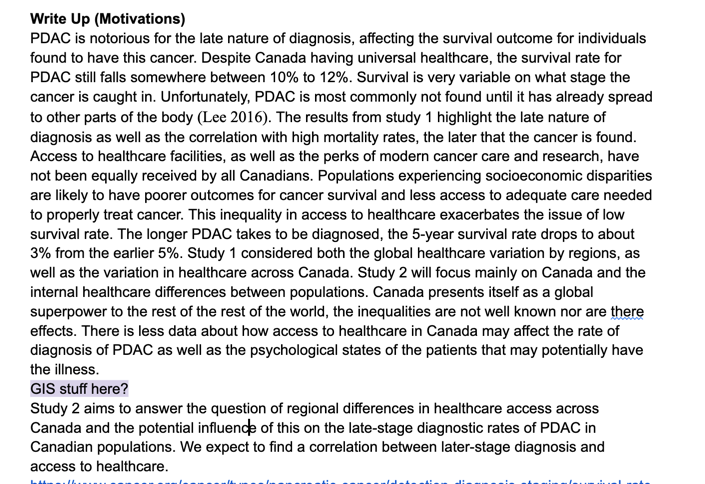

# References

1.  Kim S, Kim S, Jo JH, et al. Early response evaluation using CT and CA 19-9 in patients with pancreatic cancer of all stages undergoing first-line FOLFIRINOX treatment. *Pancreatology*. 2025;25(3):377-384. doi:https://doi.org/10.1016/j.pan.2025.02.007
‌

2. Debernardi S, O’Brien H, Algahmdi AS, et al. A combination of urinary biomarker panel and PancRISK score for earlier detection of pancreatic cancer: A case–control study. Yip-Schneider MT, ed. *PLOS Medicine*. 2020;17(12):e1003489. doi:https://doi.org/10.1371/journal.pmed.1003489
‌